<a href="https://colab.research.google.com/github/gaelosvaldor-star/Tercer-paracial-/blob/main/Jackknife.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Método Jackknife

Tenemos una muestra de $n$ datos. En esta técnica eliminamos uno de los datos para obtener $n$ muestras de tamaño $n-1$.

Para cada muestra calculamos el estadístico $\hat{\theta}_i$ y luego obtenemos el **promedio del jackknife**:

$$\theta=\frac{1}{n}\sum_{i=1}^{n}\hat{\theta}_i$$

y la **varianza**:

$$\mathrm{Var}_{Jack}=\frac{n-1}{n}\sum_{i=1}^{n}\left(\theta-\hat{\theta}_i\right)^2$$

In [ ]:
import numpy as np
import random as ran
import statistics as st
import scipy.stats as stats
import matplotlib.pyplot as plt

In [ ]:

datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

n = len(datos)

def jackknife(datos):
    n = len(datos)
    datos = np.array(datos)
    theta_i = np.empty(n)
    for i in range(n):
        muestra = np.delete(datos, i)   # quitamos el dato i -> muestra de tamaño n-1
        theta_i[i] = muestra.mean()     # estadístico (media) en la muestra i
    return theta_i

theta_i = jackknife(datos)

theta_jack = theta_i.mean()                                # promedio del jackknife
var_jack   = (n-1)/n * np.sum((theta_jack - theta_i)**2)   # varianza jackknife
ee_jack    = np.sqrt(var_jack)                             # error estándar

print(f"Media muestral original  : {st.mean(datos):.4f}")
print(f"Promedio jackknife       : {theta_jack:.4f}")
print(f"Varianza jackknife       : {var_jack:.4f}")
print(f"Error estándar jackknife : {ee_jack:.4f}")

Media muestral original  : 40.0000
Promedio jackknife       : 40.0000
Varianza jackknife       : 0.8333
Error estándar jackknife : 0.9129


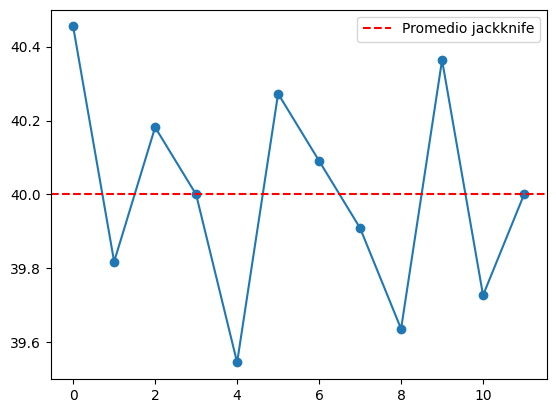

In [ ]:
promedio_jack = sum(theta_i)/len(theta_i)

plt.plot(theta_i, marker='o')
plt.axhline(y=promedio_jack, color='r', linestyle='--', label='Promedio jackknife')
plt.legend()
plt.show()